# Exploratory Data Analysis — EV Battery State-of-Health

**Dataset:** NASA Randomized Battery Usage Dataset — 28 Li-ion batteries (RW1–RW28)  
**HDF5:** `data/processed/sequences.h5` — 450,526 steps × 301 time points × 3 channels  
**Channels:** Voltage (V), Current (A), Temperature (°C)  
**Target:** State-of-Health (SOH) in % — ratio of present to initial discharge capacity  

**Figures saved to:** `results/figures/eda_0{1–7}_*.png`

In [1]:
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
print(f'matplotlib {matplotlib.__version__}, seaborn {sns.__version__}, numpy {np.__version__}')

matplotlib 3.10.7, seaborn 0.13.2, numpy 2.2.5


In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
H5_PATH     = Path('../data/processed/sequences.h5')
FIGURES_DIR = Path('../results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Battery groups ───────────────────────────────────────────────────────────
ROOM_TEMP_TRAIN = [f'RW{i}' for i in list(range(1, 9)) + list(range(15, 21))]
HOT_TEMP_TRAIN  = [f'RW{i}' for i in list(range(9, 13)) + list(range(21, 25))]
OOD_TEMP_TEST   = ['RW25', 'RW26', 'RW27', 'RW28']
OOD_DIST_TEST   = ['RW13', 'RW14']

GROUP_LABEL = {}
for b in ROOM_TEMP_TRAIN: GROUP_LABEL[b] = 'Room temp (train)'
for b in HOT_TEMP_TRAIN:  GROUP_LABEL[b] = '40°C (train)'
for b in OOD_TEMP_TEST:   GROUP_LABEL[b] = '40°C OOD test'
for b in OOD_DIST_TEST:   GROUP_LABEL[b] = 'Room temp OOD test'

GROUP_COLOR = {
    'Room temp (train)':   '#2196F3',
    '40°C (train)':        '#FF9800',
    '40°C OOD test':       '#F44336',
    'Room temp OOD test':  '#9C27B0',
}

# ── Font sizes ───────────────────────────────────────────────────────────────
TITLE_FS  = 14
LABEL_FS  = 12
TICK_FS   = 10
LEGEND_FS = 10
SAVE_DPI  = 150

print('Config ready.')
print(f'Group counts: room-temp-train={len(ROOM_TEMP_TRAIN)}, 40C-train={len(HOT_TEMP_TRAIN)}, '
      f'OOD-temp={len(OOD_TEMP_TEST)}, OOD-dist={len(OOD_DIST_TEST)}')

Config ready.
Group counts: room-temp-train=14, 40C-train=8, OOD-temp=4, OOD-dist=2


In [3]:
# Load lightweight metadata — X (~1.6 GB) is intentionally left lazy
with h5py.File(H5_PATH, 'r') as f:
    y_all          = f['y'][:]            # (450526,) float32, SOH in %
    battery_id_raw = f['battery_id'][:]   # (450526,) bytes
    block_index    = f['block_index'][:]  # (450526,) int32
    N, SEQ_LEN, N_CH = f['X'].shape      # 450526, 301, 3 — shape only, no data loaded

battery_id_arr = np.array([b.decode('ascii') for b in battery_id_raw])

print(f'Total samples : {N:,}')
print(f'Sequence shape: ({SEQ_LEN}, {N_CH})  [voltage, current, temperature]')
print(f'SOH range     : [{y_all.min():.2f}%, {y_all.max():.2f}%]  '
      f'mean={y_all.mean():.1f}%  median={np.median(y_all):.1f}%')
print()
for grp, color in GROUP_COLOR.items():
    batts  = [b for b, g in GROUP_LABEL.items() if g == grp]
    n_st   = int(sum((battery_id_arr == b).sum() for b in batts))
    print(f'  {grp:<26}: {len(batts)} batteries, {n_st:>7,} steps')

Total samples : 450,526
Sequence shape: (301, 3)  [voltage, current, temperature]
SOH range     : [0.00%, 100.26%]  mean=76.2%  median=79.9%

  Room temp (train)         : 14 batteries, 137,664 steps
  40°C (train)              : 8 batteries, 230,215 steps
  40°C OOD test             : 4 batteries,  35,494 steps
  Room temp OOD test        : 2 batteries,  47,153 steps


---
## Plot 1 — SOH Degradation Curves (All 28 Batteries)

One curve per battery. X-axis = step index within that battery (0-indexed sequential position in the HDF5). Y-axis = SOH label. Colored by temperature/condition group.

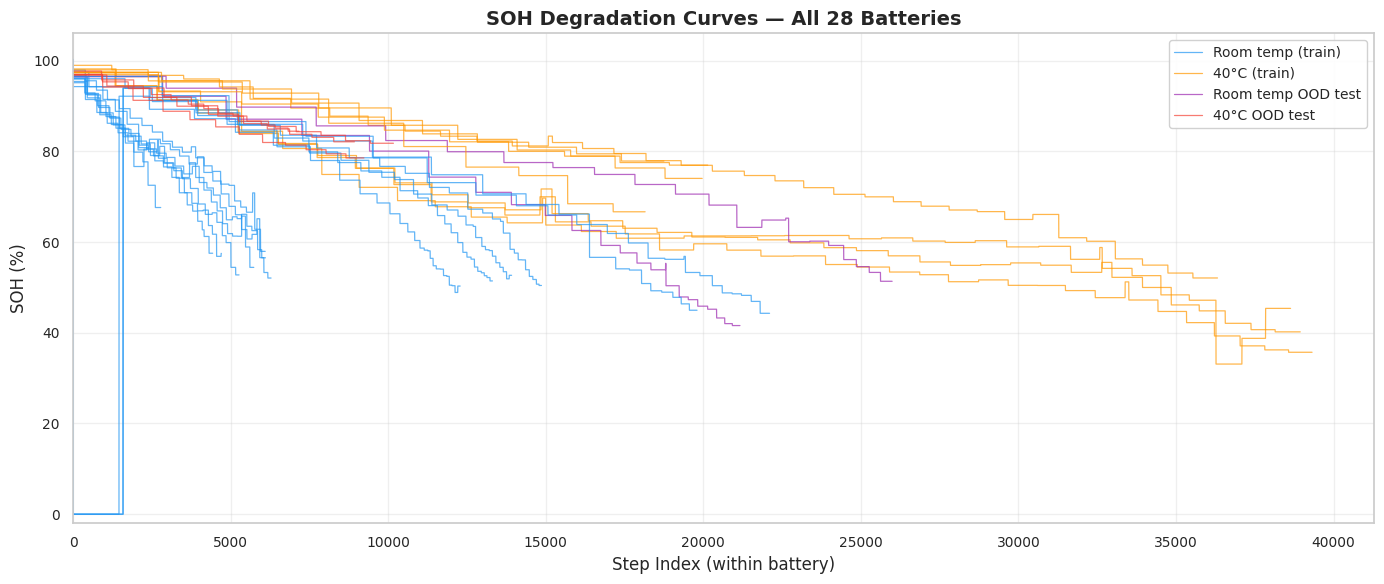

Saved: eda_01_soh_degradation.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
legend_added = set()

for batt in sorted(set(battery_id_arr), key=lambda x: int(x[2:])):
    mask     = battery_id_arr == batt
    y_bat    = y_all[mask]
    step_idx = np.arange(len(y_bat))   # 0, 1, ..., n_steps-1  (NOT block_index values)

    grp   = GROUP_LABEL[batt]
    color = GROUP_COLOR[grp]
    label = grp if grp not in legend_added else None
    if label:
        legend_added.add(grp)

    ax.plot(step_idx, y_bat, color=color, alpha=0.7, linewidth=0.9, label=label)

ax.set_xlabel('Step Index (within battery)', fontsize=LABEL_FS)
ax.set_ylabel('SOH (%)', fontsize=LABEL_FS)
ax.set_title('SOH Degradation Curves — All 28 Batteries', fontsize=TITLE_FS, fontweight='bold')
ax.tick_params(labelsize=TICK_FS)
ax.set_ylim(-2, 106)
ax.set_xlim(left=0)
ax.legend(fontsize=LEGEND_FS, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_01_soh_degradation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_01_soh_degradation.png')

---
## Plot 2 — Healthy vs Degraded Raw Curves (Battery RW9)

Battery RW9 degrades from ~97.5% to ~35.7% SOH — the widest range in the dataset. We overlay one step from early life (SOH > 90%) and one from late life (SOH < 50%). Three subplots: voltage, current, temperature.

Early life: step 0  SOH=97.5%  global_idx=113893
Late life : step 31,489  SOH=49.3%  global_idx=145382


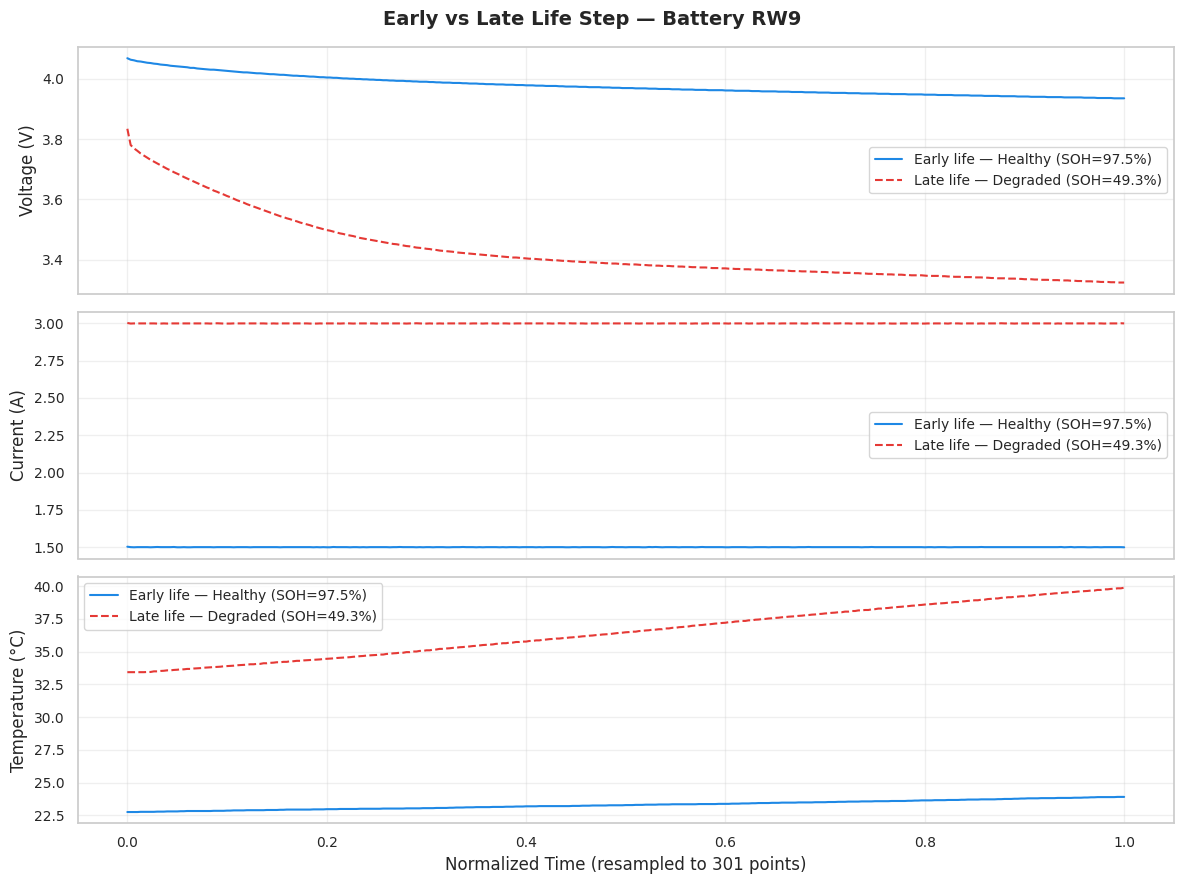

Saved: eda_02_healthy_vs_degraded.png


In [5]:
DEMO_BATTERY = 'RW9'

idx_demo = np.where(battery_id_arr == DEMO_BATTERY)[0]   # global HDF5 row indices
y_demo   = y_all[idx_demo]

# Pick the first step with SOH > 90% and the first with SOH < 50%
early_pos = int(np.where(y_demo > 90)[0][0])
late_pos  = int(np.where(y_demo < 50)[0][0])

early_global = int(idx_demo[early_pos])
late_global  = int(idx_demo[late_pos])
early_soh    = float(y_demo[early_pos])
late_soh     = float(y_demo[late_pos])

print(f'Early life: step {early_pos:,}  SOH={early_soh:.1f}%  global_idx={early_global}')
print(f'Late life : step {late_pos:,}  SOH={late_soh:.1f}%  global_idx={late_global}')

# h5py fancy indexing requires a sorted Python list
sorted_globals = sorted([early_global, late_global])
with h5py.File(H5_PATH, 'r') as f:
    x_pair = f['X'][sorted_globals]   # (2, 301, 3)

# Map back to early/late after sort
if sorted_globals[0] == early_global:
    x_early, x_late = x_pair[0], x_pair[1]
else:
    x_late, x_early = x_pair[0], x_pair[1]

t_axis = np.linspace(0, 1, SEQ_LEN)
CHANNEL_NAMES = ['Voltage (V)', 'Current (A)', 'Temperature (°C)']
EARLY_COLOR   = '#1E88E5'
LATE_COLOR    = '#E53935'

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ch_idx, (ax, ch_name) in enumerate(zip(axes, CHANNEL_NAMES)):
    ax.plot(t_axis, x_early[:, ch_idx],
            color=EARLY_COLOR, lw=1.5,
            label=f'Early life — Healthy (SOH={early_soh:.1f}%)')
    ax.plot(t_axis, x_late[:, ch_idx],
            color=LATE_COLOR, lw=1.5, linestyle='--',
            label=f'Late life — Degraded (SOH={late_soh:.1f}%)')
    ax.set_ylabel(ch_name, fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS, loc='best')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Normalized Time (resampled to 301 points)', fontsize=LABEL_FS)
fig.suptitle(f'Early vs Late Life Step — Battery {DEMO_BATTERY}',
             fontsize=TITLE_FS, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_02_healthy_vs_degraded.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_02_healthy_vs_degraded.png')

---
## Plot 3 — Step Count per Battery

Bar chart of HDF5 row count per battery. RW9–12 (40°C uniform cycling) have 5–10× more steps than room-temp batteries.

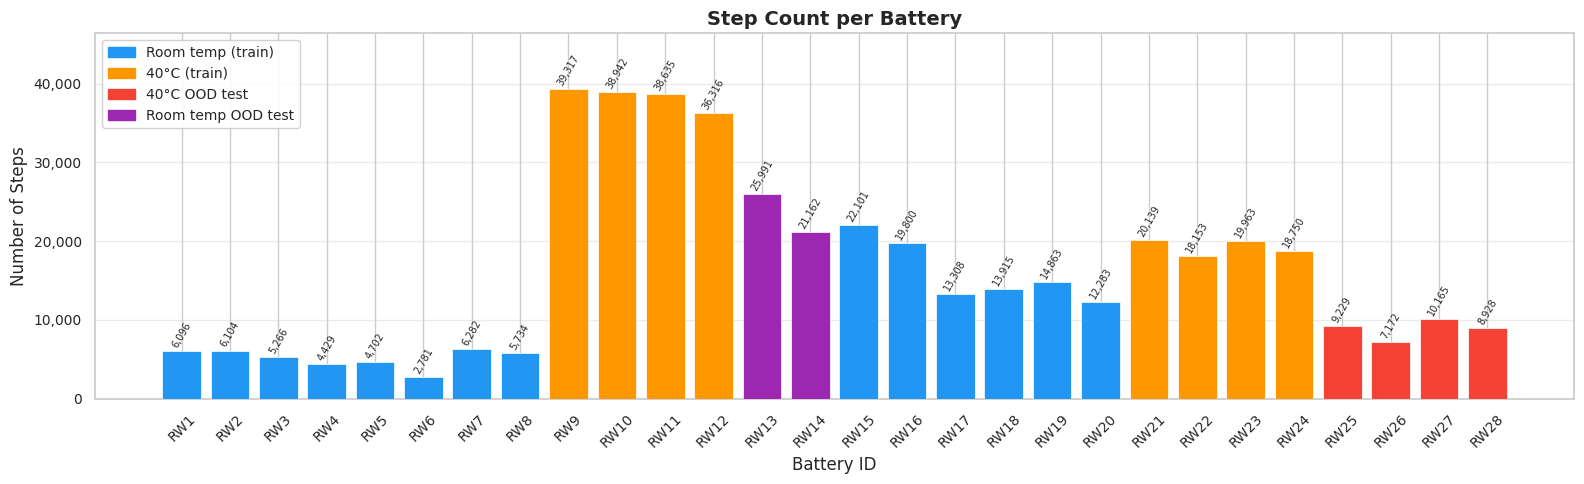

Total steps: 450,526
Saved: eda_03_samples_per_battery.png


In [6]:
battery_sorted = sorted(set(battery_id_arr), key=lambda x: int(x[2:]))
counts  = [int((battery_id_arr == b).sum()) for b in battery_sorted]
colors  = [GROUP_COLOR[GROUP_LABEL[b]] for b in battery_sorted]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(battery_sorted, counts, color=colors, edgecolor='white', linewidth=0.5, zorder=3)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 200,
            f'{count:,}',
            ha='center', va='bottom', fontsize=7, rotation=60)

ax.set_xlabel('Battery ID', fontsize=LABEL_FS)
ax.set_ylabel('Number of Steps', fontsize=LABEL_FS)
ax.set_title('Step Count per Battery', fontsize=TITLE_FS, fontweight='bold')
ax.tick_params(axis='x', labelsize=TICK_FS, rotation=45)
ax.tick_params(axis='y', labelsize=TICK_FS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_ylim(0, max(counts) * 1.18)   # headroom for labels

legend_patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COLOR.items()]
ax.legend(handles=legend_patches, fontsize=LEGEND_FS, loc='upper left', framealpha=0.9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_03_samples_per_battery.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Total steps: {sum(counts):,}')
print('Saved: eda_03_samples_per_battery.png')

---
## Plot 4 — SOH Label Distribution

Histogram of all 450,526 SOH labels. The distribution is right-skewed — most steps occur at high SOH (early battery life). The spike at SOH=0 comes from failed reference discharges in RW17–19 (a data artifact, not removed).

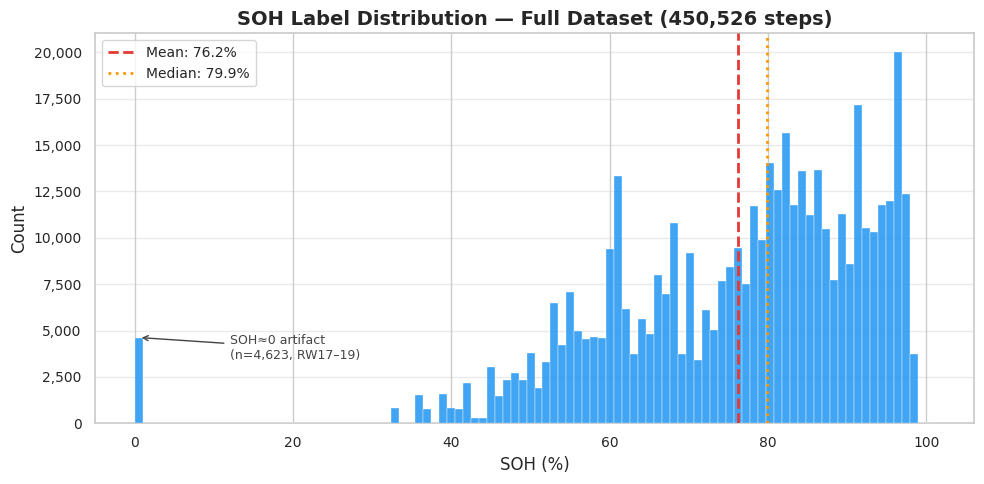

SOH: mean=76.21%, median=79.90%, std=16.80%
Saved: eda_04_soh_distribution.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(y_all, bins=100, range=(0, 101),
        color='#2196F3', edgecolor='white', linewidth=0.3, alpha=0.85, zorder=3)

mean_soh   = float(y_all.mean())
median_soh = float(np.median(y_all))
ax.axvline(mean_soh,   color='#E53935', lw=2.0, linestyle='--',
           label=f'Mean: {mean_soh:.1f}%', zorder=4)
ax.axvline(median_soh, color='#FF9800', lw=2.0, linestyle=':',
           label=f'Median: {median_soh:.1f}%', zorder=4)

n_zero = int((y_all < 0.5).sum())
if n_zero > 0:
    # Get approximate bar height near 0
    hist_vals, _ = np.histogram(y_all, bins=100, range=(0, 101))
    spike_h = hist_vals[0]
    ax.annotate(f'SOH≈0 artifact\n(n={n_zero:,}, RW17–19)',
                xy=(0.5, spike_h), xytext=(12, spike_h * 0.75),
                fontsize=9, color='#444',
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.0))

ax.set_xlabel('SOH (%)', fontsize=LABEL_FS)
ax.set_ylabel('Count', fontsize=LABEL_FS)
ax.set_title(f'SOH Label Distribution — Full Dataset ({N:,} steps)',
             fontsize=TITLE_FS, fontweight='bold')
ax.tick_params(labelsize=TICK_FS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.legend(fontsize=LEGEND_FS)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_04_soh_distribution.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'SOH: mean={mean_soh:.2f}%, median={median_soh:.2f}%, std={y_all.std():.2f}%')
print('Saved: eda_04_soh_distribution.png')

---
## Plot 5 — SOH Label Staircase (Block/Epoch Structure)

Multiple consecutive steps share the same SOH label because they all occurred between the same two reference discharge measurements. Each block (epoch) has a flat SOH plateau, creating a staircase pattern. Battery RW9 used: ~39 blocks.

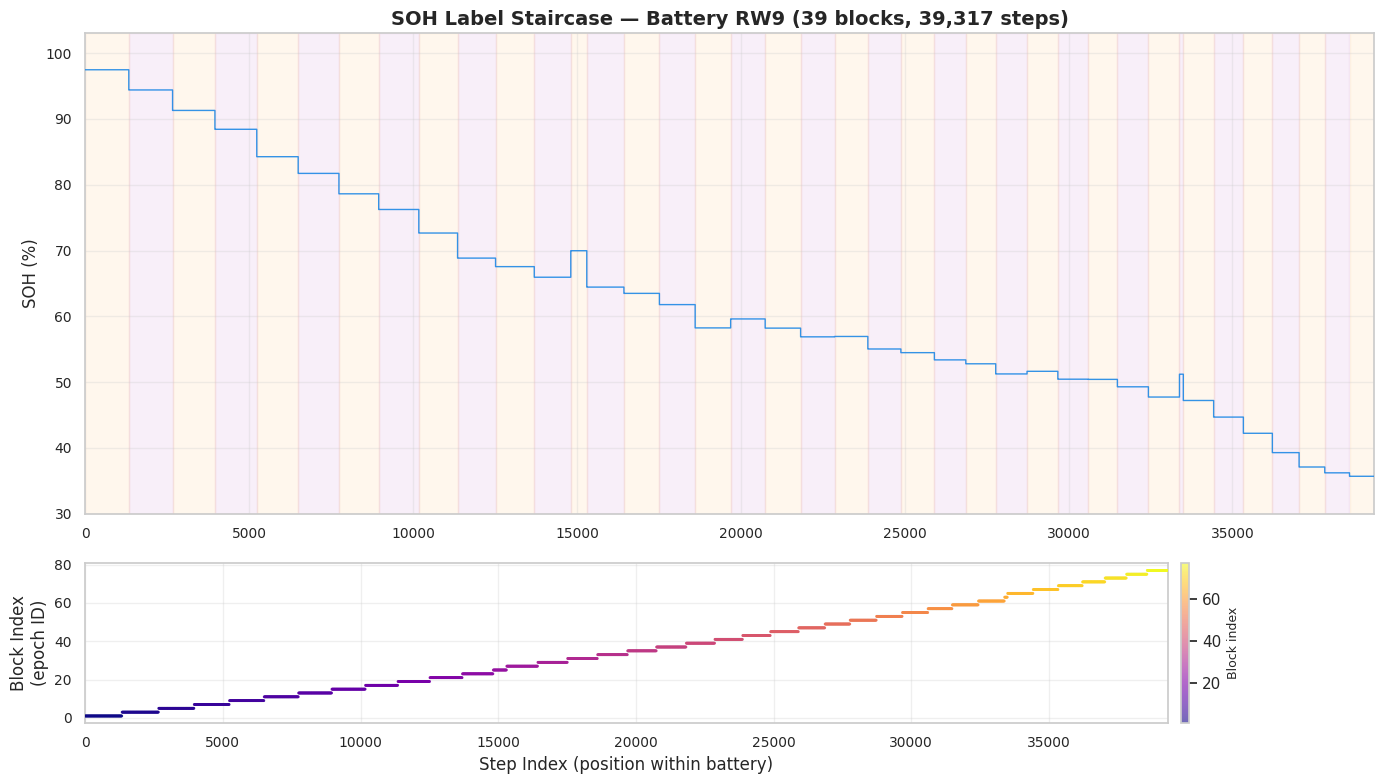

Block sizes: min=117, max=1335, median=1022
Saved: eda_05_soh_staircase.png


In [8]:
STAIRCASE_BATTERY = 'RW9'

mask_s      = battery_id_arr == STAIRCASE_BATTERY
y_s         = y_all[mask_s]
blk_s       = block_index[mask_s]
step_s      = np.arange(len(y_s))
unique_blks = np.unique(blk_s)
n_blocks    = len(unique_blks)

fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [3, 1]})

# ── Top panel: staircase curve ─────────────────────────────────────────────
ax_top = axes[0]
ax_top.plot(step_s, y_s,
            color='#1E88E5', lw=1.0, alpha=0.9,
            drawstyle='steps-post', zorder=3)

for i, blk_val in enumerate(unique_blks):
    positions = np.where(blk_s == blk_val)[0]
    ax_top.axvspan(positions[0], positions[-1],
                   alpha=0.07,
                   color='#FF9800' if i % 2 == 0 else '#9C27B0',
                   zorder=0)

ax_top.set_ylabel('SOH (%)', fontsize=LABEL_FS)
ax_top.set_title(f'SOH Label Staircase — Battery {STAIRCASE_BATTERY} '
                 f'({n_blocks} blocks, {len(y_s):,} steps)',
                 fontsize=TITLE_FS, fontweight='bold')
ax_top.tick_params(labelsize=TICK_FS)
ax_top.grid(True, alpha=0.3)
ax_top.set_ylim(30, 103)
ax_top.set_xlim(0, len(y_s))

# ── Bottom panel: block index (epoch ID) ──────────────────────────────────
ax_bot = axes[1]
sc = ax_bot.scatter(step_s[::10], blk_s[::10],
                     c=blk_s[::10].astype(float), cmap='plasma',
                     s=1, alpha=0.6, zorder=3)
ax_bot.set_xlabel('Step Index (position within battery)', fontsize=LABEL_FS)
ax_bot.set_ylabel('Block Index\n(epoch ID)', fontsize=LABEL_FS)
ax_bot.tick_params(labelsize=TICK_FS)
ax_bot.grid(True, alpha=0.3)
ax_bot.set_xlim(0, len(y_s))

cbar = fig.colorbar(sc, ax=ax_bot, orientation='vertical', pad=0.01)
cbar.set_label('Block index', fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_05_soh_staircase.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

block_sizes = [(blk_s == bv).sum() for bv in unique_blks]
print(f'Block sizes: min={min(block_sizes)}, max={max(block_sizes)}, '
      f'median={int(np.median(block_sizes))}')
print('Saved: eda_05_soh_staircase.png')

---
## Plot 6 — Cross-Temperature Comparison at Similar SOH (~80%)

Overlay one discharge step from a room-temp battery and one from a 40°C battery, both at approximately 80% SOH. Differences in the waveforms are due to temperature alone, motivating the OOD temperature split.

Room temp (RW7): step 3,083, global_idx=185671, SOH=80.34%
40°C      (RW9): step 7,741, global_idx=121634, SOH=78.62%


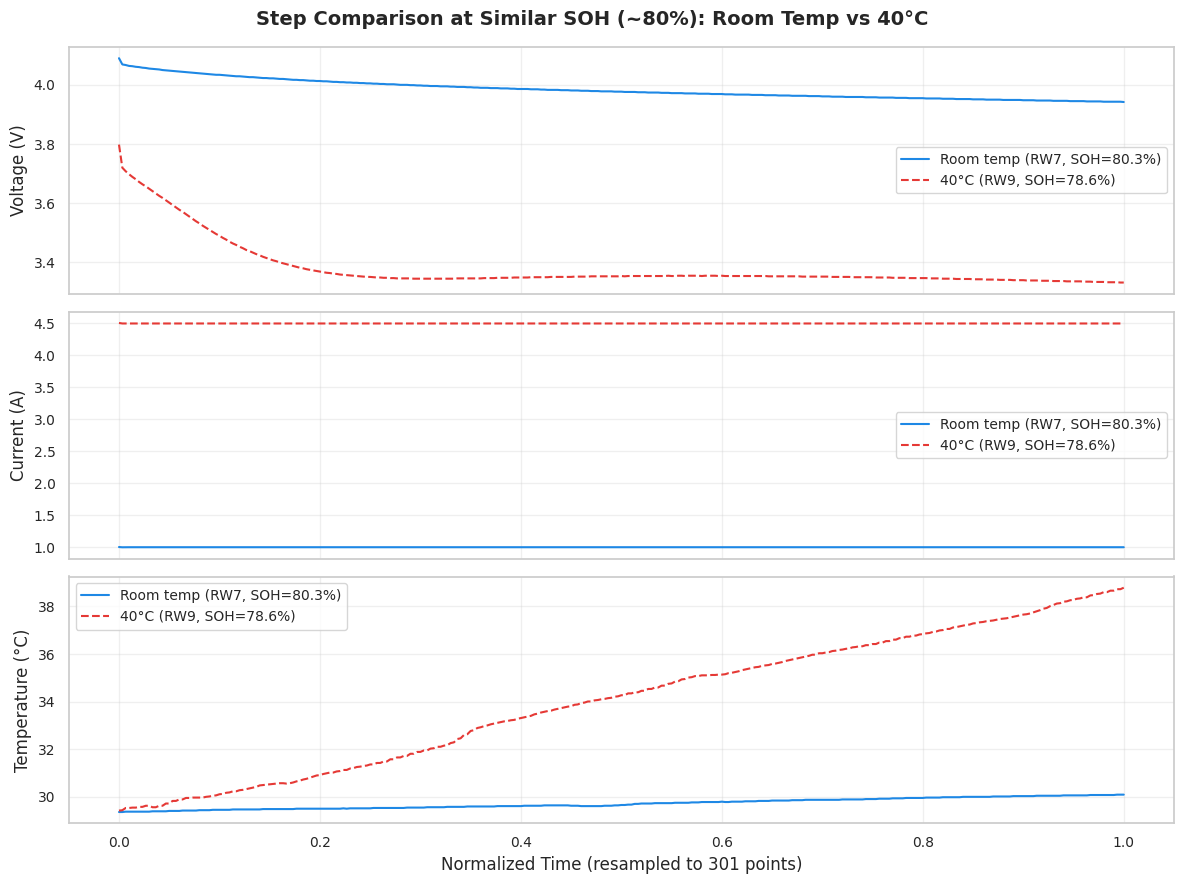

Saved: eda_06_cross_temperature.png


In [9]:
ROOM_BATT = 'RW7'   # room temp, degrades to ~52% SOH — has steps near 80%
HOT_BATT  = 'RW9'   # 40°C, degrades to ~36% SOH
TARGET_SOH = 80.0

# Find closest step to TARGET_SOH in each battery (dynamic, not hardcoded)
mask_r   = battery_id_arr == ROOM_BATT
idx_r    = np.where(mask_r)[0]
pos_r    = int(np.argmin(np.abs(y_all[mask_r] - TARGET_SOH)))
global_r = int(idx_r[pos_r])
soh_r    = float(y_all[global_r])

mask_h   = battery_id_arr == HOT_BATT
idx_h    = np.where(mask_h)[0]
pos_h    = int(np.argmin(np.abs(y_all[mask_h] - TARGET_SOH)))
global_h = int(idx_h[pos_h])
soh_h    = float(y_all[global_h])

print(f'Room temp ({ROOM_BATT}): step {pos_r:,}, global_idx={global_r}, SOH={soh_r:.2f}%')
print(f'40°C      ({HOT_BATT}): step {pos_h:,}, global_idx={global_h}, SOH={soh_h:.2f}%')

sorted_globals6 = sorted([global_r, global_h])
with h5py.File(H5_PATH, 'r') as f:
    x_pair6 = f['X'][sorted_globals6]   # (2, 301, 3)

if sorted_globals6[0] == global_r:
    x_room, x_hot = x_pair6[0], x_pair6[1]
else:
    x_hot, x_room = x_pair6[0], x_pair6[1]

t_axis = np.linspace(0, 1, SEQ_LEN)
ROOM_COLOR = '#1E88E5'
HOT_COLOR  = '#E53935'
CHANNEL_NAMES = ['Voltage (V)', 'Current (A)', 'Temperature (°C)']

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ch_idx, (ax, ch_name) in enumerate(zip(axes, CHANNEL_NAMES)):
    ax.plot(t_axis, x_room[:, ch_idx],
            color=ROOM_COLOR, lw=1.5,
            label=f'Room temp ({ROOM_BATT}, SOH={soh_r:.1f}%)')
    ax.plot(t_axis, x_hot[:, ch_idx],
            color=HOT_COLOR, lw=1.5, linestyle='--',
            label=f'40°C ({HOT_BATT}, SOH={soh_h:.1f}%)')
    ax.set_ylabel(ch_name, fontsize=LABEL_FS)
    ax.tick_params(labelsize=TICK_FS)
    ax.legend(fontsize=LEGEND_FS, loc='best')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Normalized Time (resampled to 301 points)', fontsize=LABEL_FS)
fig.suptitle(f'Step Comparison at Similar SOH (~{TARGET_SOH:.0f}%): Room Temp vs 40°C',
             fontsize=TITLE_FS, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_06_cross_temperature.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: eda_06_cross_temperature.png')

---
## Plot 7 — Channel Value Distributions (Boxplots)

Distribution of raw voltage, current, and temperature values across the dataset. A random sample of 2,000 steps × 301 points ≈ 602,000 values per channel (~7 MB total). Corrupted temperature readings (RW2/RW18 artifacts, values < 0) are filtered before plotting.

Temperature corruption: 12,408 / 602,000 values filtered (T ≤ 0, from RW2/RW18 MATLAB artifacts)


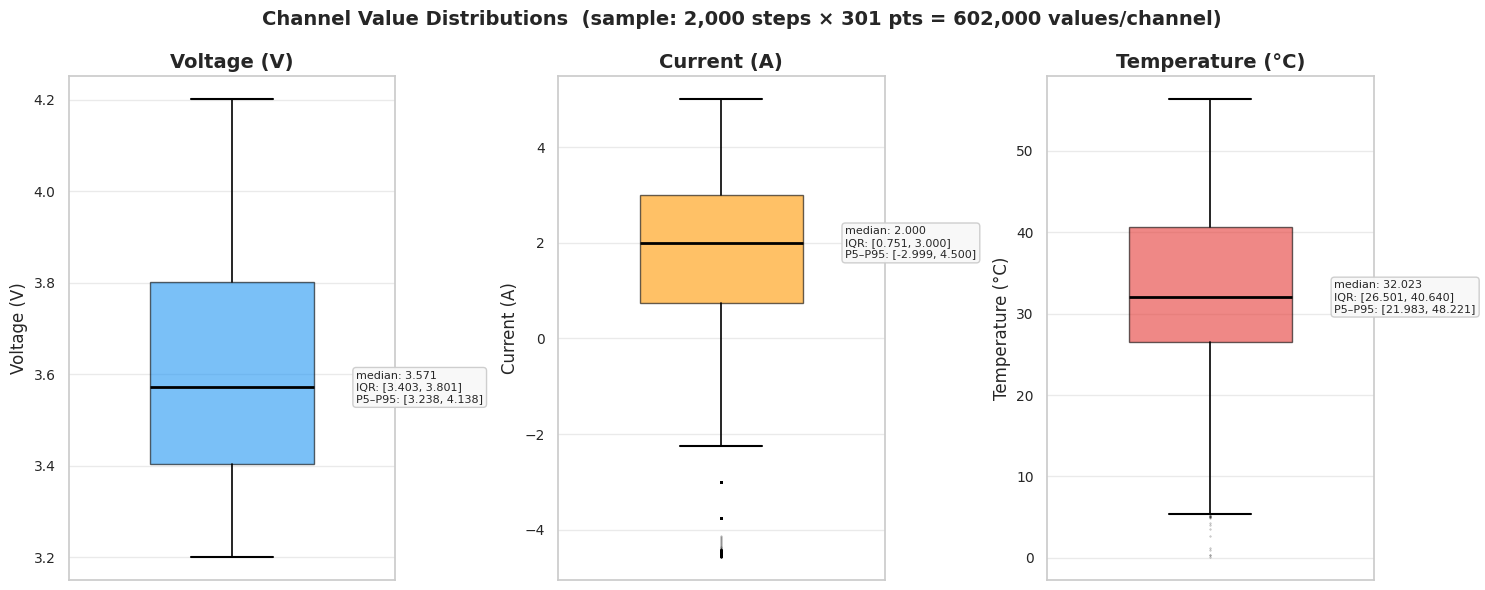

Voltage     : [3.200, 4.201] V
Current     : [-4.576, 5.008] A
Temp (clean): [0.1, 56.3] °C
Saved: eda_07_channel_distributions.png


In [10]:
N_SAMPLE_STEPS = 2000
np.random.seed(42)
sample_indices = np.sort(
    np.random.choice(N, size=N_SAMPLE_STEPS, replace=False)
).tolist()   # sorted list required for h5py fancy indexing

with h5py.File(H5_PATH, 'r') as f:
    x_sample = f['X'][sample_indices]   # (2000, 301, 3)

v_flat = x_sample[:, :, 0].flatten()          # Voltage
i_flat = x_sample[:, :, 1].flatten()          # Current
t_flat = x_sample[:, :, 2].flatten()          # Temperature (raw)
t_flat_clean = t_flat[t_flat > 0]             # filter corrupted T artifacts

n_corrupted_T = int((t_flat <= 0).sum())
print(f'Temperature corruption: {n_corrupted_T:,} / {len(t_flat):,} values filtered '
      f'(T ≤ 0, from RW2/RW18 MATLAB artifacts)')

channel_data   = [v_flat, i_flat, t_flat_clean]
channel_names  = ['Voltage (V)', 'Current (A)', 'Temperature (°C)']
channel_colors = ['#2196F3', '#FF9800', '#E53935']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, data, name, color in zip(axes, channel_data, channel_names, channel_colors):
    bp = ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        widths=0.5,
        showfliers=True,
        flierprops=dict(marker='.', markersize=1, alpha=0.3, color='#999'),
        medianprops=dict(color='black', lw=2.0),
        boxprops=dict(facecolor=color, alpha=0.6),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.5),
    )

    p5, p25, p50, p75, p95 = np.percentile(data, [5, 25, 50, 75, 95])
    stats_text = (f'median: {p50:.3f}\n'
                  f'IQR: [{p25:.3f}, {p75:.3f}]\n'
                  f'P5–P95: [{p5:.3f}, {p95:.3f}]')
    ax.text(1.38, p50, stats_text, va='center', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f8f8f8',
                      edgecolor='#ccc', alpha=0.95))

    ax.set_xticks([])
    ax.set_ylabel(name, fontsize=LABEL_FS)
    ax.set_title(name, fontsize=TITLE_FS, fontweight='bold')
    ax.tick_params(labelsize=TICK_FS)
    ax.grid(axis='y', alpha=0.4)

fig.suptitle(f'Channel Value Distributions  '
             f'(sample: {N_SAMPLE_STEPS:,} steps × {SEQ_LEN} pts = {N_SAMPLE_STEPS*SEQ_LEN:,} values/channel)',
             fontsize=TITLE_FS, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'eda_07_channel_distributions.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()

print(f'Voltage     : [{v_flat.min():.3f}, {v_flat.max():.3f}] V')
print(f'Current     : [{i_flat.min():.3f}, {i_flat.max():.3f}] A')
print(f'Temp (clean): [{t_flat_clean.min():.1f}, {t_flat_clean.max():.1f}] °C')
print('Saved: eda_07_channel_distributions.png')

---
## Summary

| Plot | Filename | Description |
|------|----------|-------------|
| 1 | `eda_01_soh_degradation.png` | SOH degradation curves, all 28 batteries |
| 2 | `eda_02_healthy_vs_degraded.png` | Early vs late life waveforms (RW9) |
| 3 | `eda_03_samples_per_battery.png` | Step count per battery |
| 4 | `eda_04_soh_distribution.png` | SOH label histogram |
| 5 | `eda_05_soh_staircase.png` | Block epoch step-function structure (RW9) |
| 6 | `eda_06_cross_temperature.png` | Room temp vs 40°C at ~80% SOH |
| 7 | `eda_07_channel_distributions.png` | V, I, T channel boxplots |

**Key findings:**
- RW9–12 (40°C) accumulate 36K–39K steps each — 5–10× more than room-temp batteries
- RW17–19 have SOH≈0 blocks from failed reference discharges (data artifact)
- Temperature channel is corrupted in RW2 and RW18 (MATLAB v7.3 loader artifact)
- SOH distribution is right-skewed: most steps occur at high SOH (early battery life)
- At similar SOH (~80%), 40°C batteries show elevated baseline temperature and distinct voltage profiles — motivates temperature as an OOD generalization challenge